<a href="https://colab.research.google.com/github/dsharma44418-ai/CELEBAL_INTERNSHIP/blob/main/Dheeraj_CIFAR10_ANN_CNN_Assignment_Project_Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

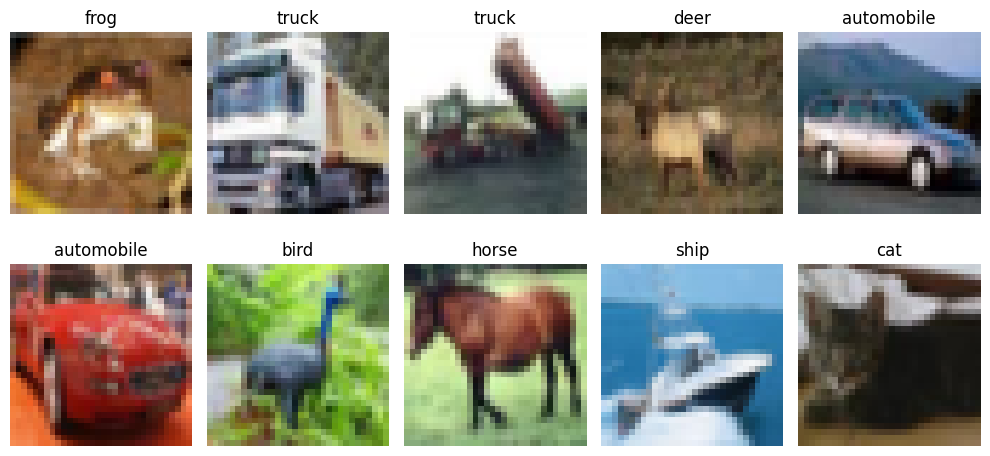

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2645 - loss: 2.0097 - val_accuracy: 0.3138 - val_loss: 1.8766
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3142 - loss: 1.8777 - val_accuracy: 0.3726 - val_loss: 1.7709
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3334 - loss: 1.8294 - val_accuracy: 0.3872 - val_loss: 1.7432
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3492 - loss: 1.7903 - val_accuracy: 0.3810 - val_loss: 1.7402
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3610 - loss: 1.7595 - val_accuracy: 0.3934 - val_loss: 1.7375
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3681 - loss: 1.7415 - val_accuracy: 0.4116 - val_loss: 1.6755
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3763 - loss: 1.7187 - val_accuracy: 0.4144 - val_loss: 1.6635
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3828 - loss: 1.7019 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4246 - loss: 1.6283
ANN Test Accuracy: 0.4246000051498413


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4734 - loss: 1.4755 - val_accuracy: 0.4832 - val_loss: 1.5425
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6133 - loss: 1.1075 - val_accuracy: 0.6230 - val_loss: 1.0638
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6773 - loss: 0.9313 - val_accuracy: 0.6112 - val_loss: 1.1671
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7201 - loss: 0.8086 - val_accuracy: 0.6600 - val_loss: 1.0235
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7529 - loss: 0.7161 - val_accuracy: 0.7192 - val_loss: 0.8231
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7780 - loss: 0.6348 - val_accuracy: 0.7032 - val_loss: 0.8504
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7984 - loss: 0.5709 - val_accuracy: 0.7282 - val_loss: 0.7934
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8196 - loss: 0.5059 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7167 - loss: 0.9907
CNN Test Accuracy: 0.71670001745224


## 📈 Compare Learning Curves

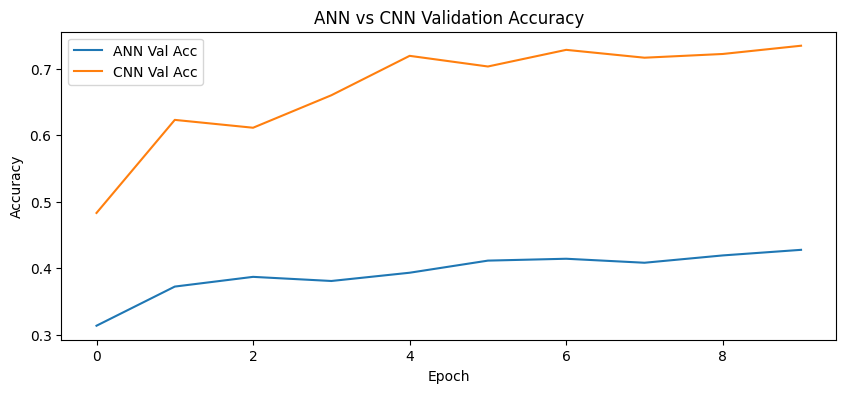

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4246
1,CNN,0.7167


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

Task 1 - Increase ANN Layers and Observe Performance

In [12]:
# Task 1: Building an upgraded ANN with increased network depth and capacity
advanced_ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

advanced_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Starting training for Deep ANN Architecture...")
adv_ann_history = advanced_ann.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Starting training for Deep ANN Architecture...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2411 - loss: 2.0546 - val_accuracy: 0.2854 - val_loss: 1.9505
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2926 - loss: 1.9190 - val_accuracy: 0.3276 - val_loss: 1.8627
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3051 - loss: 1.8929 - val_accuracy: 0.3336 - val_loss: 1.8546
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3167 - loss: 1.8654 - val_accuracy: 0.3780 - val_loss: 1.7770
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3252 - loss: 1.8440 - val_accuracy: 0.3768 - val_loss: 1.7841
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3303 - loss: 1.8232 - val_accuracy: 0.3822 - val_loss: 1.7699
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3362 - loss: 1.8163 - val_accuracy: 0.3656 - val_loss: 1.7547
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - ac

Task 5 - Define Data Augmentation Configuration

In [13]:
# Task 5: Defining the image transformation pipeline for better generalization
data_augmentation_layer = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
print("Data augmentation pipeline initialized successfully.")

Data augmentation pipeline initialized successfully.


Task 2 (Strictly 32 -> 64 -> 128 Filters) & 4 Add EarlyStopping

In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Task 2: Build CNN Architecture with sequential filters (32 -> 64 -> 128)
task2_cnn_model = models.Sequential([
    # First Layer: 32 Filters
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Second Layer: 64 Filters
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Third Layer: 128 Filters
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

# Task 4: Configure EarlyStopping to monitor validation loss
task4_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Compile the model
task2_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Task 2 and Task 4 configured successfully.")

Task 2 and Task 4 configured successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Task 3 - Train the Advanced CNN for 20 Epochs

In [16]:
# Task 3: Executing extended training loop optimized up to 20 epochs
print("Executing advanced CNN training routine...")
task2_4_history = task2_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[task4_early_stopping],
    batch_size=64
)

Executing advanced CNN training routine...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.4769 - loss: 1.4852 - val_accuracy: 0.5034 - val_loss: 1.4327
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6090 - loss: 1.1100 - val_accuracy: 0.5098 - val_loss: 1.5188
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6701 - loss: 0.9409 - val_accuracy: 0.6086 - val_loss: 1.1415
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7083 - loss: 0.8299 - val_accuracy: 0.6484 - val_loss: 0.9759
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7400 - loss: 0.7457 - val_accuracy: 0.6950 - val_loss: 0.9002
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7640 - loss: 0.6761 - val_accuracy: 0.5122 - val_loss: 1.8062
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7859 - loss: 0.6094 - val_accuracy: 0.7286 - val_loss: 0.8193
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accur

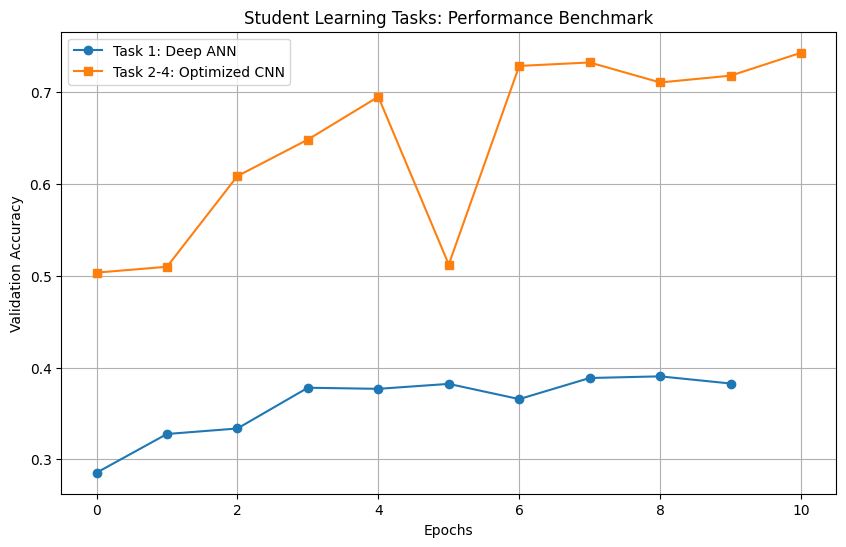

In [18]:
import matplotlib.pyplot as plt

# Plotting performance metrics to contrast final student learning tasks
plt.figure(figsize=(10, 6))

# Checking and plotting ANN history if available
if 'adv_ann_history' in locals():
    plt.plot(adv_ann_history.history['val_accuracy'], label='Task 1: Deep ANN', marker='o')
elif 'ann_history' in locals():
    plt.plot(ann_history.history['val_accuracy'], label='Baseline ANN', marker='o')

# Plotting the newly trained optimized CNN history
if 'task2_4_history' in locals():
    plt.plot(task2_4_history.history['val_accuracy'], label='Task 2-4: Optimized CNN', marker='s')

plt.title('Student Learning Tasks: Performance Benchmark')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Task 5: Defining Data Augmentation Pipeline
data_augmentation_pipeline = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Task 2 & 5: CNN Architecture with Augmentation and 32->64->128 Filters
augmented_cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation_pipeline, # Integrating Task 5

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

# Task 4: EarlyStopping Configuration
augmented_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

augmented_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Task 3: Training for 20 Epochs
print("Starting Final Training with Data Augmentation...")
augmented_history = augmented_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    callbacks=[augmented_early_stopping],
    batch_size=64
)

Starting Final Training with Data Augmentation...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.4150 - loss: 1.6472 - val_accuracy: 0.4802 - val_loss: 1.4315
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5117 - loss: 1.3688 - val_accuracy: 0.5458 - val_loss: 1.2528
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.5589 - loss: 1.2462 - val_accuracy: 0.5506 - val_loss: 1.2601
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5863 - loss: 1.1760 - val_accuracy: 0.6276 - val_loss: 1.0630
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6068 - loss: 1.1151 - val_accuracy: 0.6146 - val_loss: 1.1115
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6263 - loss: 1.0677 - val_accuracy: 0.6840 - val_loss: 0.9222
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.6402 - loss: 1.0299 - val_accuracy: 0.6650 - val_loss: 0.9709
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 1